In [1]:
# =============================================================
# Drosophila validation: input ablation + spatial blocked split
# Models: DynML, direct ridge, persistence
# Metrics: Pearson r, RMSE, MAE, R2
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.integrate import solve_ivp
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Config
# -----------------------------
file = "valid_genes_filtered.csv"
assert os.path.exists(file), f"File not found: {file}"

N = 150
t_initial, t_final = 0, 4
ridge_alpha = 1e-6
test_size = 0.2

seeds = [17, 42, 101, 202, 303, 404, 505, 606, 707, 808]

input_types = [
    "gene_only",
    "coords_only",
    "gene_plus_coords"
]

split_types = [
    "random_cell",
    "spatial_block_x"
]

# -----------------------------
# Load table
# -----------------------------
df = pd.read_csv(file, header=None)
print("Loaded data shape:", df.shape)

# Your previous indexing
coords_rows = df.iloc[2:5, 1:].astype(float).values
expr_rows = df.iloc[5:, 1:].astype(float).values

num_cells = expr_rows.shape[1]
num_gene_rows = expr_rows.shape[0]
assert num_gene_rows % 6 == 0, "Expected gene rows to be multiple of 6"

num_genes = num_gene_rows // 6
num_timepoints = 6
num_transitions = num_timepoints - 1

print(f"Cells = {num_cells}, Genes = {num_genes}, Transitions = {num_transitions}")

# -----------------------------
# Build gene transition input/output matrices
# Rows: gene-transition features
# Columns: cells
# -----------------------------
X_gene_list = []
Y_list = []

for g in range(num_genes):
    block = expr_rows[g * num_timepoints:(g + 1) * num_timepoints, :]
    for t in range(num_transitions):
        X_gene_list.append(block[t, :].copy())
        Y_list.append(block[t + 1, :].copy())

X_gene = np.vstack(X_gene_list)
Y = np.vstack(Y_list)

print("X_gene shape:", X_gene.shape)
print("Y shape:", Y.shape)
print("coords shape:", coords_rows.shape)

# -----------------------------
# Metrics
# -----------------------------
def compute_metrics(y_true, y_pred):
    yt = np.asarray(y_true).reshape(-1)
    yp = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)

    if np.std(yt) > 0 and np.std(yp) > 0:
        r, p = pearsonr(yt, yp)
    else:
        r, p = np.nan, np.nan

    return {
        "pearson_r": r,
        "pearson_p": p,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

# -----------------------------
# Input construction
# -----------------------------
def make_input_matrix(input_type):
    if input_type == "gene_only":
        return X_gene.copy()

    if input_type == "coords_only":
        return coords_rows.copy()

    if input_type == "gene_plus_coords":
        return np.vstack([coords_rows, X_gene])

    raise ValueError(f"Unknown input_type: {input_type}")

# -----------------------------
# Splits
# -----------------------------
def make_split(split_type, seed):
    cells = np.arange(num_cells)

    if split_type == "random_cell":
        train_cells, test_cells = train_test_split(
            cells,
            test_size=test_size,
            random_state=seed
        )
        return train_cells, test_cells

    if split_type == "spatial_block_x":
        # Spatially blocked validation using x-coordinate quantile blocks.
        # Hold out one x-spatial block, selected by seed.
        x_coord = coords_rows[0, :]
        n_blocks = 5

        # Convert x coordinates into quantile bins
        quantiles = np.quantile(x_coord, np.linspace(0, 1, n_blocks + 1))
        quantiles[0] -= 1e-9
        quantiles[-1] += 1e-9

        block_id = np.digitize(x_coord, quantiles[1:-1], right=False)

        held_block = seed % n_blocks

        test_cells = cells[block_id == held_block]
        train_cells = cells[block_id != held_block]

        return train_cells, test_cells

    raise ValueError(f"Unknown split_type: {split_type}")

# -----------------------------
# Lorenz reservoir
# -----------------------------
def make_reservoir_params(N, rng):
    param_range_reservoir = [
        (9.9, 10.1),
        (27.9, 28.1),
        (2.65, 2.70)
    ]

    reservoir_params = np.array([
        [rng.uniform(low, high) for (low, high) in param_range_reservoir]
        + [rng.uniform(1, 8)]
        for _ in range(N)
    ])

    return reservoir_params

def lorenz_system(t, Xvec, params):
    X = Xvec.reshape(N, 3)

    sigma = params[:, 0]
    rho = params[:, 1]
    beta = params[:, 2]
    tau = params[:, 3]

    dx = sigma * (X[:, 1] - X[:, 0]) / tau
    dy = (X[:, 0] * (rho - X[:, 2]) - X[:, 1]) / tau
    dz = (X[:, 0] * X[:, 1] - beta * X[:, 2]) / tau

    return np.stack([dx, dy, dz], axis=1).flatten()

def compute_reservoir_features(X_norm, seed):
    rng = np.random.default_rng(seed)

    M = X_norm.shape[0]
    D = X_norm.shape[1]

    reservoir_params = make_reservoir_params(N, rng)
    R = rng.uniform(-1.0, 1.0, size=(3 * N, M))

    phi = np.zeros((3 * N, D))

    for i in range(D):
        if i % 500 == 0:
            print(f"      reservoir sample {i + 1}/{D}")

        init = R @ X_norm[:, i]

        sol = solve_ivp(
            lorenz_system,
            (t_initial, t_final),
            init,
            t_eval=[t_final],
            args=(reservoir_params,),
            rtol=1e-6,
            atol=1e-9
        )

        if not sol.success:
            raise RuntimeError(f"Reservoir integration failed for sample {i}: {sol.message}")

        phi[:, i] = sol.y[:, -1]

    return phi

# -----------------------------
# One evaluation run
# -----------------------------
def run_one_experiment(input_type, split_type, seed):
    print("\n" + "=" * 80)
    print(f"Input type: {input_type} | Split: {split_type} | Seed: {seed}")
    print("=" * 80)

    X_input = make_input_matrix(input_type)

    train_cells, test_cells = make_split(split_type, seed)

    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()

    X_train_raw = X_input[:, train_cells].T
    X_test_raw = X_input[:, test_cells].T

    Y_train_raw = Y[:, train_cells].T
    Y_test_raw = Y[:, test_cells].T

    X_train_norm = scaler_X.fit_transform(X_train_raw).T
    X_test_norm = scaler_X.transform(X_test_raw).T

    Y_train_norm = scaler_Y.fit_transform(Y_train_raw).T
    Y_test_norm = scaler_Y.transform(Y_test_raw).T

    X_all_norm = np.zeros_like(X_input, dtype=float)
    X_all_norm[:, train_cells] = X_train_norm
    X_all_norm[:, test_cells] = X_test_norm

    Y_train_true = Y[:, train_cells]
    Y_test_true = Y[:, test_cells]

    rows = []

    # ---------------------------------------------------------
    # DynML
    # ---------------------------------------------------------
    phi = compute_reservoir_features(X_all_norm, seed=seed)

    phi_train = phi[:, train_cells].T
    phi_test = phi[:, test_cells].T

    readout = Ridge(alpha=ridge_alpha, fit_intercept=True)
    readout.fit(phi_train, Y_train_norm.T)

    pred_train_norm = readout.predict(phi_train).T
    pred_test_norm = readout.predict(phi_test).T

    pred_train = scaler_Y.inverse_transform(pred_train_norm.T).T
    pred_test = scaler_Y.inverse_transform(pred_test_norm.T).T

    for split_name, y_true, y_pred in [
        ("train", Y_train_true, pred_train),
        ("test", Y_test_true, pred_test)
    ]:
        rows.append({
            "model": "DynML",
            "input_type": input_type,
            "split_type": split_type,
            "split": split_name,
            "seed": seed,
            "num_train_cells": len(train_cells),
            "num_test_cells": len(test_cells),
            **compute_metrics(y_true, y_pred)
        })

    # ---------------------------------------------------------
    # Direct ridge baseline
    # ---------------------------------------------------------
    ridge = Ridge(alpha=1.0, fit_intercept=True)
    ridge.fit(X_train_norm.T, Y_train_norm.T)

    ridge_train_norm = ridge.predict(X_train_norm.T).T
    ridge_test_norm = ridge.predict(X_test_norm.T).T

    ridge_train = scaler_Y.inverse_transform(ridge_train_norm.T).T
    ridge_test = scaler_Y.inverse_transform(ridge_test_norm.T).T

    for split_name, y_true, y_pred in [
        ("train", Y_train_true, ridge_train),
        ("test", Y_test_true, ridge_test)
    ]:
        rows.append({
            "model": "Direct ridge",
            "input_type": input_type,
            "split_type": split_type,
            "split": split_name,
            "seed": seed,
            "num_train_cells": len(train_cells),
            "num_test_cells": len(test_cells),
            **compute_metrics(y_true, y_pred)
        })

    # ---------------------------------------------------------
    # Persistence baseline
    # Only valid when gene-transition rows are present.
    # For gene_only and gene_plus_coords, persistence is Y_hat = X_gene.
    # Not valid for coords_only.
    # ---------------------------------------------------------
    if input_type in ["gene_only", "gene_plus_coords"]:
        persist_train = X_gene[:, train_cells]
        persist_test = X_gene[:, test_cells]

        for split_name, y_true, y_pred in [
            ("train", Y_train_true, persist_train),
            ("test", Y_test_true, persist_test)
        ]:
            rows.append({
                "model": "Persistence",
                "input_type": input_type,
                "split_type": split_type,
                "split": split_name,
                "seed": seed,
                "num_train_cells": len(train_cells),
                "num_test_cells": len(test_cells),
                **compute_metrics(y_true, y_pred)
            })

    return rows

# -----------------------------
# Run all experiments
# -----------------------------
all_rows = []

for split_type in split_types:
    for input_type in input_types:
        for seed in seeds:
            all_rows.extend(run_one_experiment(input_type, split_type, seed))


results_df = pd.DataFrame(all_rows)

results_df.to_csv(
    "drosophila_ablation_spatial_validation.csv",
    index=False
)

print("\nSaved: drosophila_ablation_spatial_validation.csv")
display(results_df.head())

/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/var/folders/rp/3svz678x3dlfx98xp15q82b12rg7gw/T/ipykernel_30126/2018972650.py:45: DtypeWarning: Columns (0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 30, 30: 31, 31: 32, 32: 33, 33: 34, 34: 35, 35: 36, 36: 37, 37: 38, 38: 39, 39: 40, 40: 41, 41: 42, 42: 43, 43: 44, 44: 45, 45: 46, 46: 47, 47: 48, 48: 49, 49: 50, 50: 51, 51: 52, 52: 53, 53: 54, 54: 55, 55: 56, 56: 57, 57: 58, 58: 59, 59: 60, 60: 61, 61: 62, 62: 63, 63: 64, 64: 65, 65: 66, 66: 67, 67: 68, 68: 69, 69: 70, 70: 71, 71: 72, 72: 73, 73: 74, 74: 75, 75: 76, 76: 77, 77: 78, 78: 79, 79: 80, 80: 81, 

Loaded data shape: (167, 6079)
Cells = 6078, Genes = 27, Transitions = 5
X_gene shape: (135, 6078)
Y shape: (135, 6078)
coords shape: (3, 6078)

Input type: gene_only | Split: random_cell | Seed: 17
      reservoir sample 1/6078
      reservoir sample 501/6078
      reservoir sample 1001/6078
      reservoir sample 1501/6078
      reservoir sample 2001/6078
      reservoir sample 2501/6078
      reservoir sample 3001/6078
      reservoir sample 3501/6078
      reservoir sample 4001/6078
      reservoir sample 4501/6078
      reservoir sample 5001/6078
      reservoir sample 5501/6078
      reservoir sample 6001/6078

Input type: gene_only | Split: random_cell | Seed: 42
      reservoir sample 1/6078
      reservoir sample 501/6078
      reservoir sample 1001/6078
      reservoir sample 1501/6078
      reservoir sample 2001/6078
      reservoir sample 2501/6078
      reservoir sample 3001/6078
      reservoir sample 3501/6078
      reservoir sample 4001/6078
      reservoir sample 4501/

,model,input_type,split_type,split,seed,num_train_cells,num_test_cells,pearson_r,pearson_p,rmse,mae,r2
0,DynML,gene_only,random_cell,train,17,4862,1216,0.969236,0.0,0.053884,0.040111,0.939418
1,DynML,gene_only,random_cell,test,17,4862,1216,0.961479,0.0,0.059792,0.044285,0.924399
2,Direct ridge,gene_only,random_cell,train,17,4862,1216,0.994661,0.0,0.022592,0.006566,0.989350
3,Direct ridge,gene_only,random_cell,test,17,4862,1216,0.994200,0.0,0.023387,0.006752,0.988433
4,Persistence,gene_only,random_cell,train,17,4862,1216,0.897688,0.0,0.098813,0.065267,0.796270


In [3]:
# -----------------------------
# Run only missing experiments and append to final CSV
# -----------------------------

final_csv = "drosophila_ablation_spatial_validation.csv"

seeds = [
    17, 42, 101, 202, 303,
    404, 505, 606, 707, 808,
    909, 1001, 1111, 1212, 1313,
    1414, 1515, 1616, 1717, 1818
]

# Load existing results if present
if os.path.exists(final_csv):
    existing_df = pd.read_csv(final_csv)
    print(f"Loaded existing results: {final_csv}")
    print("Existing shape:", existing_df.shape)
else:
    existing_df = pd.DataFrame()
    print("No existing results found. Starting from scratch.")

# Build set of completed experiment combinations
required_key_cols = ["input_type", "split_type", "seed"]

if not existing_df.empty and all(col in existing_df.columns for col in required_key_cols):
    completed = set(
        existing_df[required_key_cols]
        .drop_duplicates()
        .apply(lambda row: (row["input_type"], row["split_type"], int(row["seed"])), axis=1)
        .tolist()
    )
else:
    completed = set()

print("Completed experiment combinations:", len(completed))

new_rows = []

for split_type in split_types:
    for input_type in input_types:
        for seed in seeds:

            key = (input_type, split_type, int(seed))

            if key in completed:
                print(f"Skipping existing: input={input_type} | split={split_type} | seed={seed}")
                continue

            print(f"Running missing: input={input_type} | split={split_type} | seed={seed}")

            rows = run_one_experiment(input_type, split_type, seed)
            new_rows.extend(rows)

            # Save incrementally after each completed seed/input/split combination
            new_rows_df = pd.DataFrame(new_rows)

            combined_df = pd.concat(
                [existing_df, new_rows_df],
                ignore_index=True
            )

            # Remove accidental duplicate rows
            # Keep all rows for train/test and model, but avoid exact duplicate reruns.
            dedup_cols = [
                "model",
                "input_type",
                "split_type",
                "split",
                "seed"
            ]

            combined_df = combined_df.drop_duplicates(
                subset=dedup_cols,
                keep="last"
            )

            combined_df.to_csv(final_csv, index=False)

            print(f"Updated saved file: {final_csv}")
            print("Current combined shape:", combined_df.shape)

# Final reload and display
results_df = pd.read_csv(final_csv)

print("\nFinal saved file:", final_csv)
print("Final shape:", results_df.shape)
print("Final seeds:", sorted(results_df["seed"].unique()))

display(results_df.head())

Loaded existing results: drosophila_ablation_spatial_validation.csv
Existing shape: (320, 12)
Completed experiment combinations: 60
Skipping existing: input=gene_only | split=random_cell | seed=17
Skipping existing: input=gene_only | split=random_cell | seed=42
Skipping existing: input=gene_only | split=random_cell | seed=101
Skipping existing: input=gene_only | split=random_cell | seed=202
Skipping existing: input=gene_only | split=random_cell | seed=303
Skipping existing: input=gene_only | split=random_cell | seed=404
Skipping existing: input=gene_only | split=random_cell | seed=505
Skipping existing: input=gene_only | split=random_cell | seed=606
Skipping existing: input=gene_only | split=random_cell | seed=707
Skipping existing: input=gene_only | split=random_cell | seed=808
Running missing: input=gene_only | split=random_cell | seed=909

Input type: gene_only | Split: random_cell | Seed: 909
      reservoir sample 1/6078
      reservoir sample 501/6078
      reservoir sample 1001/

,model,input_type,split_type,split,seed,num_train_cells,num_test_cells,pearson_r,pearson_p,rmse,mae,r2
0,DynML,gene_only,random_cell,train,17,4862,1216,0.969236,0.0,0.053884,0.040111,0.939418
1,DynML,gene_only,random_cell,test,17,4862,1216,0.961479,0.0,0.059792,0.044285,0.924399
2,Direct ridge,gene_only,random_cell,train,17,4862,1216,0.994661,0.0,0.022592,0.006566,0.989350
3,Direct ridge,gene_only,random_cell,test,17,4862,1216,0.994200,0.0,0.023387,0.006752,0.988433
4,Persistence,gene_only,random_cell,train,17,4862,1216,0.897688,0.0,0.098813,0.065267,0.796270


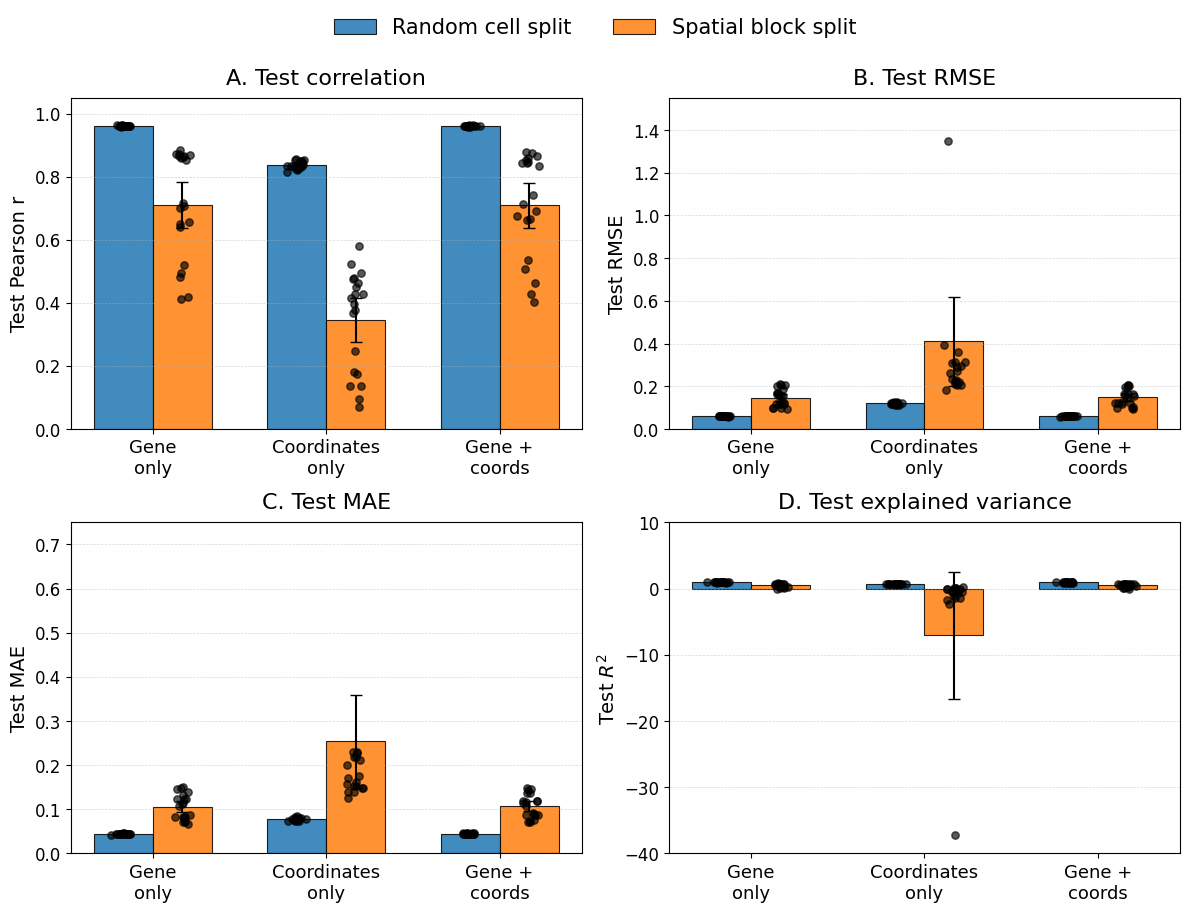

In [6]:
# =============================================================
# Improved Drosophila ablation + spatial validation figure
# Mean bars + individual seed points + 95% CI
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("drosophila_ablation_spatial_validation.csv")

test_df = results_df[
    (results_df["split"] == "test")
    & (results_df["model"] == "DynML")
].copy()

input_order = ["gene_only", "coords_only", "gene_plus_coords"]
split_order = ["random_cell", "spatial_block_x"]

pretty_input = {
    "gene_only": "Gene\nonly",
    "coords_only": "Coordinates\nonly",
    "gene_plus_coords": "Gene +\ncoords"
}

pretty_split = {
    "random_cell": "Random cell split",
    "spatial_block_x": "Spatial block split"
}

test_df["input_type"] = pd.Categorical(
    test_df["input_type"],
    categories=input_order,
    ordered=True
)

test_df["split_type"] = pd.Categorical(
    test_df["split_type"],
    categories=split_order,
    ordered=True
)

summary_df = (
    test_df
    .groupby(["input_type", "split_type"], as_index=False)
    .agg(
        mean_pearson_r=("pearson_r", "mean"),
        std_pearson_r=("pearson_r", "std"),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        n_seeds=("seed", "nunique")
    )
)

for metric in ["pearson_r", "rmse", "mae", "r2"]:
    summary_df[f"ci_{metric}"] = (
        1.96 * summary_df[f"std_{metric}"] / np.sqrt(summary_df["n_seeds"])
    )

summary_df.to_csv(
    "drosophila_ablation_spatial_validation_dynml_summary.csv",
    index=False
)

metrics = [
    ("pearson_r", "mean_pearson_r", "ci_pearson_r", "Test Pearson r", "A. Test correlation"),
    ("rmse", "mean_rmse", "ci_rmse", "Test RMSE", "B. Test RMSE"),
    ("mae", "mean_mae", "ci_mae", "Test MAE", "C. Test MAE"),
    ("r2", "mean_r2", "ci_r2", r"Test $R^2$", "D. Test explained variance")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

x = np.arange(len(input_order))
width = 0.34

rng = np.random.default_rng(123)

for ax, (raw_col, mean_col, ci_col, ylabel, title) in zip(axes, metrics):

    for j, split_type in enumerate(split_order):
        df_s = (
            summary_df[summary_df["split_type"] == split_type]
            .sort_values("input_type")
        )

        offset = (j - 0.5) * width
        xpos = x + offset

        ax.bar(
            xpos,
            df_s[mean_col].values,
            width=width,
            yerr=df_s[ci_col].values,
            capsize=4,
            linewidth=0.8,
            edgecolor="black",
            label=pretty_split[split_type],
            alpha=0.85
        )

        # Overlay individual seed points
        for k, input_type in enumerate(input_order):
            vals = test_df[
                (test_df["input_type"] == input_type)
                & (test_df["split_type"] == split_type)
            ][raw_col].values

            jitter = rng.normal(0, 0.025, size=len(vals))

            ax.scatter(
                np.full(len(vals), x[k] + offset) + jitter,
                vals,
                s=28,
                color="black",
                alpha=0.65,
                zorder=3
            )

    ax.set_title(title, fontsize=16, pad=10)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [pretty_input[i] for i in input_order],
        fontsize=13
    )
    ax.tick_params(axis="y", labelsize=12)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# Readable y-axis ranges
axes[0].set_ylim(0.0, 1.05)
axes[1].set_ylim(0.0, 1.55)
axes[2].set_ylim(0.0, 0.75)

# Keep full negative R2 visible but avoid huge white space
axes[3].set_ylim(-40, 10)

# Shared legend for all panels
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=False,
    fontsize=15,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "drosophila_ablation_spatial_validation_seed_points.jpeg",
    dpi=900,
    bbox_inches="tight"
)

plt.savefig(
    "drosophila_ablation_spatial_validation_seed_points.pdf",
    bbox_inches="tight"
)

plt.show()